# LSTM Demand Forecasting — Baseline
Predict next-day units_sold per SKU using 30-day lookback windows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import lightning.pytorch as pl
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from lightning.pytorch.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path

# Paths
processed = Path("../Data/Processed")
model_dir = Path("../Models/Forecasting")
report_dir = Path("../Reports/Model_Reports")

# Config
LOOKBACK = 30
EPOCHS   = 200
BATCH    = 32

FEATURES = [
    "units_roll_7", "units_roll_14", "units_roll_30",
    "rev_roll_7",   "rev_roll_14",   "rev_roll_30",
    "units_lag_1",  "units_lag_7",   "units_lag_14",
    "day_of_week",  "month",         "is_weekend",  "is_dec",
    "spike_lag_1",  "spike_count_30"
]

TARGET = "units_sold"

print("Setup done. Features:", len(FEATURES))

Setup done. Features: 15


In [2]:
# Load saved dataset
df = pd.read_csv(processed / "retail_product_daily_demand.csv", parse_dates=["Date"])
df = df.sort_values(["StockCode", "Date"]).reset_index(drop=True)

print("Shape:", df.shape)
print("SKUs:", df["StockCode"].nunique())
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
df.head()

Shape: (7250, 20)
SKUs: 10
Date range: 2009-12-15 to 2011-12-09


,StockCode,Date,units_sold,revenue,n_invoices,units_roll_7,units_roll_14,units_roll_30,rev_roll_7,rev_roll_14,rev_roll_30,units_lag_1,units_lag_7,units_lag_14,day_of_week,day_of_month,month,quarter,is_weekend,is_dec
0,20725,2009-12-15,10,16.5,1,51.428571,48.142857,48.142857,82.000000,76.578571,76.578571,55.0,53.0,163.0,1,15,12,4,0,1
1,20725,2009-12-16,50,82.5,3,45.285714,37.214286,45.600000,71.864286,59.975000,72.573333,10.0,150.0,10.0,2,16,12,4,0,1
2,20725,2009-12-17,26,42.9,4,31.000000,40.071429,45.875000,51.150000,64.689286,73.193750,50.0,40.0,30.0,3,17,12,4,0,1
3,20725,2009-12-18,40,66.0,3,29.000000,39.785714,44.705882,47.850000,64.217857,71.411765,26.0,31.0,70.0,4,18,12,4,0,1
4,20725,2009-12-19,0,0.0,0,30.285714,37.642857,44.444444,49.971429,60.682143,71.111111,40.0,0.0,0.0,5,19,12,4,1,1


In [3]:
# Add spike features (built here so they stay clean per-SKU)
limits = df.groupby("StockCode")["units_sold"].quantile(0.95)
df["is_spike"] = (df["units_sold"] > df["StockCode"].map(limits)).astype(int)

df["spike_lag_1"]   = df.groupby("StockCode")["is_spike"].shift(1)
df["spike_count_30"] = df.groupby("StockCode")["is_spike"].transform(
    lambda x: x.shift(1).rolling(30, min_periods=1).sum()
)

df = df.drop(columns=["is_spike"])
df = df.dropna(subset=FEATURES).reset_index(drop=True)

skus = df["StockCode"].unique().tolist()

print("Shape after adding spike features:", df.shape)
print("SKUs:", len(skus))
df[["StockCode", "Date", "units_sold", "spike_lag_1", "spike_count_30"]].head(10)

Shape after adding spike features: (7240, 22)
SKUs: 10


,StockCode,Date,units_sold,spike_lag_1,spike_count_30
0,20725,2009-12-16,50,0.0,0.0
1,20725,2009-12-17,26,0.0,0.0
2,20725,2009-12-18,40,0.0,0.0
3,20725,2009-12-19,0,0.0,0.0
4,20725,2009-12-20,40,0.0,0.0
5,20725,2009-12-21,110,0.0,0.0
6,20725,2009-12-22,0,0.0,0.0
7,20725,2009-12-23,0,0.0,0.0
8,20725,2009-12-24,0,0.0,0.0
9,20725,2009-12-25,0,0.0,0.0


In [4]:
# Helper: build (X, y) sequence pairs from a dataframe
def make_sequences(data, features, target, lookback):
    X = data[features].values
    y = data[target].values
    X_out, y_out = [], []
    for i in range(lookback, len(data)):
        X_out.append(X[i - lookback : i])
        y_out.append(y[i])
    return np.array(X_out, dtype=np.float32), np.array(y_out, dtype=np.float32)

In [5]:
# LSTM model
class LSTMModel(pl.LightningModule):

    def __init__(self, input_size, hidden_size=64, num_layers=2, lr=0.001):
        super().__init__()
        self.save_hyperparameters()
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers,
                               dropout=0.2, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc      = nn.Linear(hidden_size, 1)
        self.loss_fn = nn.SmoothL1Loss()
        self.lr      = lr

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :]))

    def training_step(self, batch, _):
        X, y = batch
        loss = self.loss_fn(self(X), y)
        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        X, y = batch
        loss = self.loss_fn(self(X), y)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.lr)
        sch = ReduceLROnPlateau(opt, mode="min", patience=10, factor=0.5)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sch, "monitor": "val_loss"}}

In [6]:
# Helper: train one SKU and return metrics
def train_sku(sku_df, features, target, lookback, epochs, batch_size, verbose=False):

    split    = int(len(sku_df) * 0.90)
    train_df = sku_df.iloc[:split].copy()
    val_df   = sku_df.iloc[split - lookback:].copy()

    # Scale
    xs = StandardScaler()
    ys = StandardScaler()
    train_df["target_log"]    = np.log1p(train_df[target])
    val_df["target_log"]      = np.log1p(val_df[target])
    train_df["target_scaled"] = ys.fit_transform(train_df[["target_log"]])
    val_df["target_scaled"]   = ys.transform(val_df[["target_log"]])
    train_df[features]        = xs.fit_transform(train_df[features])
    val_df[features]          = xs.transform(val_df[features])

    # Sequences
    X_train, y_train = make_sequences(train_df, features, "target_scaled", lookback)
    X_val,   y_val   = make_sequences(val_df,   features, "target_scaled", lookback)

    # Loaders
    tl = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train).unsqueeze(1)),
                    batch_size=batch_size, shuffle=False)
    vl = DataLoader(TensorDataset(torch.tensor(X_val),   torch.tensor(y_val).unsqueeze(1)),
                    batch_size=batch_size, shuffle=False)

    # Train
    model = LSTMModel(input_size=len(features))
    early_stop = EarlyStopping(monitor="val_loss", patience=20, mode="min", verbose=False)
    trainer = pl.Trainer(max_epochs=epochs, callbacks=[early_stop],
                         logger=False, enable_checkpointing=False,
                         enable_model_summary=False, enable_progress_bar=verbose)
    trainer.fit(model, tl, vl)

    # Predict
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in vl:
            preds.extend(model(X_batch).numpy().flatten())

    actual    = np.expm1(ys.inverse_transform(y_val.reshape(-1, 1)).flatten())
    predicted = np.expm1(ys.inverse_transform(np.array(preds).reshape(-1, 1)).flatten())
    actual    = np.rint(actual).clip(min=0)
    predicted = predicted.clip(min=0)

    # Metrics
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    nz   = actual > 0
    mape = np.mean(np.abs((actual[nz] - predicted[nz]) / actual[nz])) * 100
    wape = np.sum(np.abs(actual - predicted)) / np.sum(actual) * 100

    return model, {"MAE": round(mae, 2), "RMSE": round(rmse, 2),
                   "MAPE": round(mape, 2), "WAPE": round(wape, 2)}

In [7]:
# Quick test on first SKU before running all 10
test_sku = skus[0]
sku_data = df[df["StockCode"] == test_sku].sort_values("Date").copy()

print(f"Testing on SKU: {test_sku}  ({len(sku_data)} rows)")

_, test_metrics = train_sku(sku_data, FEATURES, TARGET, LOOKBACK, EPOCHS, BATCH, verbose=True)

print("\nResults:")
for k, v in test_metrics.items():
    print(f"  {k}: {v}")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Testing on SKU: 20725  (724 rows)
                                                                           

c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 40: 100%|██████████| 20/20 [00:00<00:00, 87.84it/s, train_loss_step=0.160, val_loss=0.141, train_loss_epoch=0.141]  

Results:
  MAE: 28.65
  RMSE: 44.29
  MAPE: 121.23999786376953
  WAPE: 59.709999084472656


In [8]:
# Train all SKUs
results = []
trained_models = {}

for sku in skus:
    sku_data = df[df["StockCode"] == sku].sort_values("Date").copy()
    model, metrics = train_sku(sku_data, FEATURES, TARGET, LOOKBACK, EPOCHS, BATCH)
    trained_models[sku] = model
    results.append({"StockCode": sku, **metrics})
    print(f"{sku}  |  MAPE: {metrics['MAPE']}%  |  WAPE: {metrics['WAPE']}%")

results_df = pd.DataFrame(results)
print("\n--- Average ---")
print(results_df[["MAE","RMSE","MAPE","WAPE"]].mean().round(2))
results_df

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connector

20725  |  MAPE: 105.05000305175781%  |  WAPE: 57.34000015258789%


c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 T

20727  |  MAPE: 91.83999633789062%  |  WAPE: 54.5099983215332%


c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 T

...

c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 T

85099B  |  MAPE: 108.4800033569336%  |  WAPE: 69.69000244140625%


c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


85123A  |  MAPE: 129.00999450683594%  |  WAPE: 72.13999938964844%

--- Average ---
MAE      44.67
RMSE     86.36
MAPE    138.35
WAPE     70.04
dtype: float64


,StockCode,MAE,RMSE,MAPE,WAPE
0,20725,27.52,42.77,105.050003,57.340000
1,20727,18.26,30.41,91.839996,54.509998
2,20914,11.80,17.66,178.639999,66.080002
3,21080,23.01,37.71,226.119995,90.099998
4,21212,48.41,84.93,203.110001,73.190002
5,21754,4.01,6.80,56.790001,66.059998
6,21931,30.27,54.53,168.130005,83.080002
7,84879,89.05,179.73,116.349998,68.260002
8,85099B,119.09,241.64,108.480003,69.690002
9,85123A,75.30,167.46,129.009995,72.139999


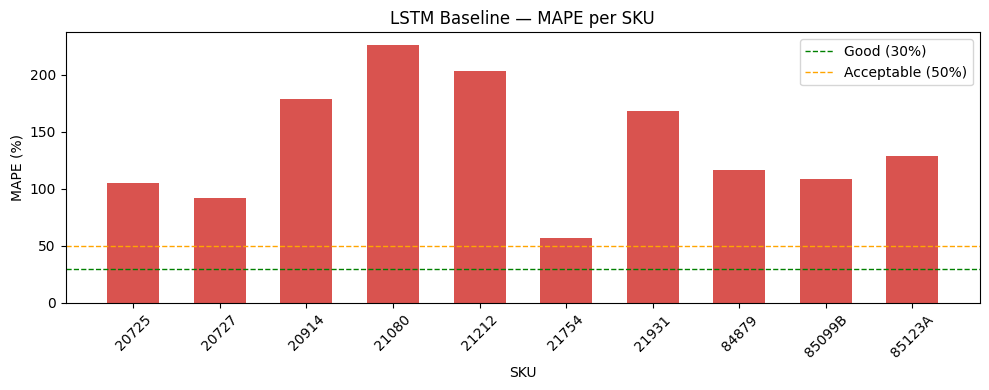

In [9]:
# Plot MAPE per SKU
fig, ax = plt.subplots(figsize=(10, 4))
colors  = ["#d9534f" if v > 50 else "#5bc0de" if v > 30 else "#5cb85c"
           for v in results_df["MAPE"]]

ax.bar(results_df["StockCode"].astype(str), results_df["MAPE"], color=colors, width=0.6)
ax.axhline(30, color="green",  linestyle="--", linewidth=1, label="Good (30%)")
ax.axhline(50, color="orange", linestyle="--", linewidth=1, label="Acceptable (50%)")
ax.set_title("LSTM Baseline — MAPE per SKU")
ax.set_xlabel("SKU")
ax.set_ylabel("MAPE (%)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../Reports/Figure/6-LSTM_MAPE_per_SKU.png", dpi=150)
plt.show()

In [10]:
# Save results + best model
results_df.to_csv(report_dir / "6-LSTM_Baseline_Metrics.csv", index=False)
print("Metrics saved.")

best_sku = results_df.loc[results_df["WAPE"].idxmin(), "StockCode"]
torch.save(trained_models[best_sku].state_dict(),
           model_dir / "lstm_baseline.pt")
print(f"Best model saved: SKU {best_sku}  (WAPE: {results_df.loc[results_df['WAPE'].idxmin(), 'WAPE']}%)")

Metrics saved.
Best model saved: SKU 20727  (WAPE: 54.5099983215332%)


In [76]:
results_df.to_csv("../Reports/Model_Reports/6-LSTM_Baseline_Metrics.csv",index=False)

print("LSTM baseline metrics saved successfully.")

LSTM baseline metrics saved successfully.
